In [1]:
# Help for read.table
?read.table


## 2. Search help by subject

In [2]:
# Search R help by subject
help.search("data input")


## 3. Online help

In [3]:
# Open online help
help()

# Open HTML browser interface to R help
help.start()


starting httpd help server ...
 done



If the browser launched by 'xdg-open' is already running, it is *not*
    restarted, and you must switch to its window.
Otherwise, be patient ...


## 4. Find the package containing a function

In [4]:
# Find the package in which lowess is located
find("lowess")


[1] "package:stats"

## 5. Search for objects matching a name

In [5]:
# Find objects whose names match "lm"
apropos("lm")


[1] ".colMeans"       ".lm.fit"         "colMeans"        "confint.lm"     
 [5] "contr.helmert"   "dummy.coef.lm"   "glm"             "glm.control"    
 [9] "glm.fit"         "KalmanForecast"  "KalmanLike"      "KalmanRun"      
[13] "KalmanSmooth"    "kappa.lm"        "lm"              "lm.fit"         
[17] "lm.influence"    "lm.wfit"         "model.matrix.lm" "nlm"            
[21] "nlminb"          "predict.glm"     "predict.lm"      "residuals.glm"  
[25] "residuals.lm"    "summary.glm"     "summary.lm"

## 6. Worked examples of functions


lm> require(graphics)

lm> ## Annette Dobson (1990) "An Introduction to Generalized Linear Models".
lm> ## Page 9: Plant Weight Data.
lm> ctl <- c(4.17,5.58,5.18,6.11,4.50,4.61,5.17,4.53,5.33,5.14)

lm> trt <- c(4.81,4.17,4.41,3.59,5.87,3.83,6.03,4.89,4.32,4.69)

lm> group <- gl(2, 10, 20, labels = c("Ctl","Trt"))

lm> weight <- c(ctl, trt)

lm> lm.D9 <- lm(weight ~ group)

lm> lm.D90 <- lm(weight ~ group - 1) # omitting intercept

lm> ## No test: 
lm> ##D anova(lm.D9)
lm> ##D summary(lm.D90)
lm> ## End(No test)
lm> opar <- par(mfrow = c(2,2), oma = c(0, 0, 1.1, 0))

lm> plot(lm.D9, las = 1)      # Residuals, Fitted, ...

lm> par(opar)

lm> ## Don't show: 
lm> ## model frame :
lm> stopifnot(identical(lm(weight ~ group, method = "model.frame"),
lm+                     model.frame(lm.D9)))

lm> ## End(Don't show)
lm> ### less simple examples in "See Also" above
lm> 
lm> 
lm> 


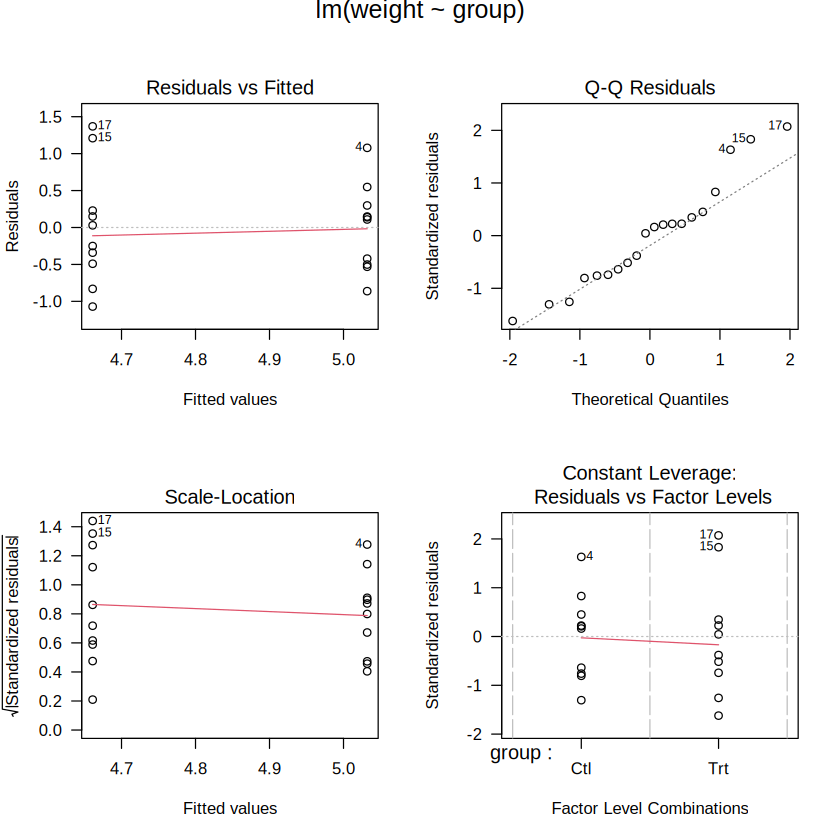

In [6]:
# Display the worked example for linear models
example(lm)


## 7. Demonstration of R functions

The notes use demonstrations to show what R can do.




	demo(persp)
	---- ~~~~~

> ### Demos for  persp()  plots   -- things not in  example(persp)
> ### -------------------------
> 
> require(datasets)

> require(grDevices); require(graphics)

> ## (1) The Obligatory Mathematical surface.
> ##     Rotated sinc function.
> 
> x <- seq(-10, 10, length.out = 50)

> y <- x

> rotsinc <- function(x,y)
+ {
+     sinc <- function(x) { y <- sin(x)/x ; y[is.na(y)] <- 1; y }
+     10 * sinc( sqrt(x^2+y^2) )
+ }

> sinc.exp <- expression(z == Sinc(sqrt(x^2 + y^2)))

> z <- outer(x, y, rotsinc)

> oldpar <- par(bg = "white")

> persp(x, y, z, theta = 30, phi = 30, expand = 0.5, col = "lightblue")

> title(sub=".")## work around persp+plotmath bug

> title(main = sinc.exp)

> persp(x, y, z, theta = 30, phi = 30, expand = 0.5, col = "lightblue",
+       ltheta = 120, shade = 0.75, ticktype = "detailed",
+       xlab = "X", ylab = "Y", zlab = "Z")


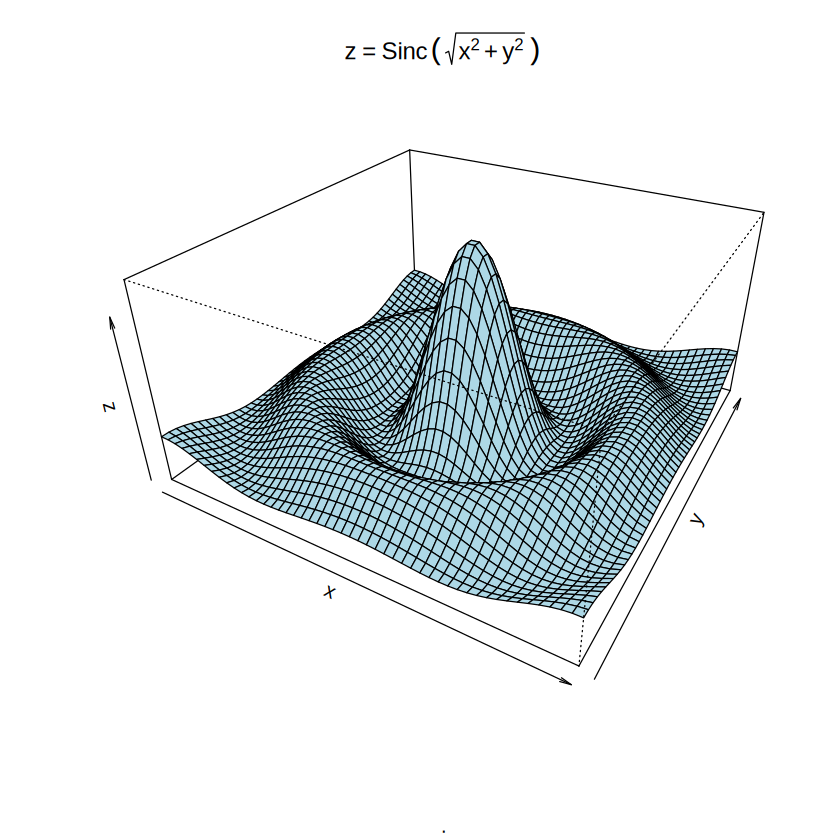


> title(sub=".")## work around persp+plotmath bug

> title(main = sinc.exp)

> ## (2) Visualizing a simple DEM model
> 
> z <- 2 * volcano        # Exaggerate the relief

> x <- 10 * (1:nrow(z))   # 10 meter spacing (S to N)

> y <- 10 * (1:ncol(z))   # 10 meter spacing (E to W)

> persp(x, y, z, theta = 120, phi = 15, scale = FALSE, axes = FALSE)


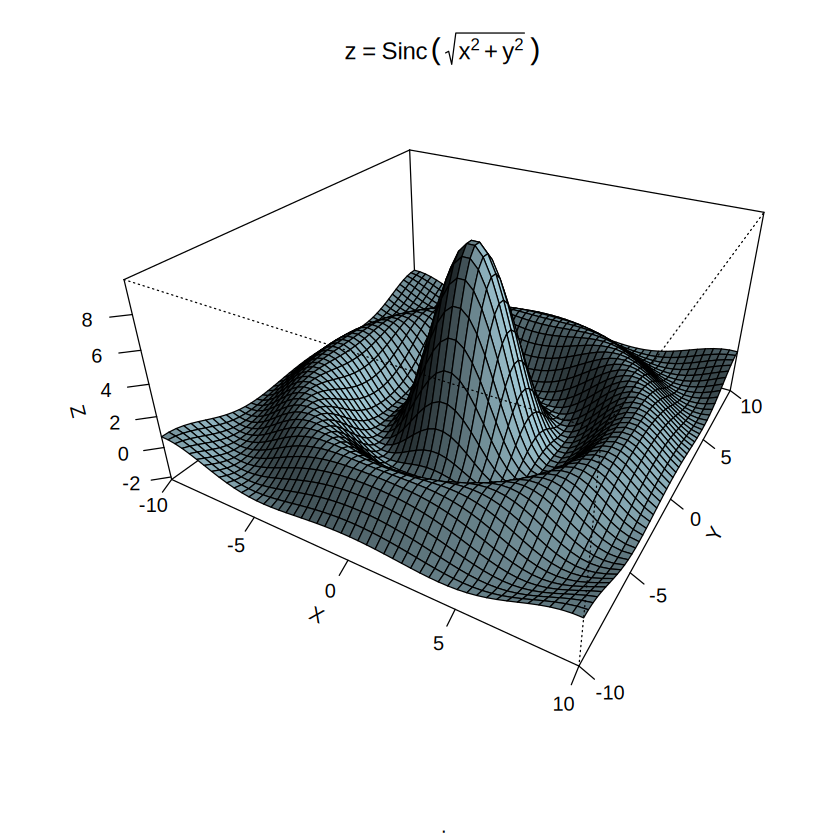


> ## (3) Now something more complex
> ##     We border the surface, to make it more "slice like"
> ##     and color the top and sides of the surface differently.
> 
> z0 <- min(z) - 20

> z <- rbind(z0, cbind(z0, z, z0), z0)

> x <- c(min(x) - 1e-10, x, max(x) + 1e-10)

> y <- c(min(y) - 1e-10, y, max(y) + 1e-10)

> fill <- matrix("green3", nrow = nrow(z)-1, ncol = ncol(z)-1)

> fill[ , i2 <- c(1,ncol(fill))] <- "gray"

> fill[i1 <- c(1,nrow(fill)) , ] <- "gray"

> par(bg = "lightblue")

> persp(x, y, z, theta = 120, phi = 15, col = fill, scale = FALSE, axes = FALSE)


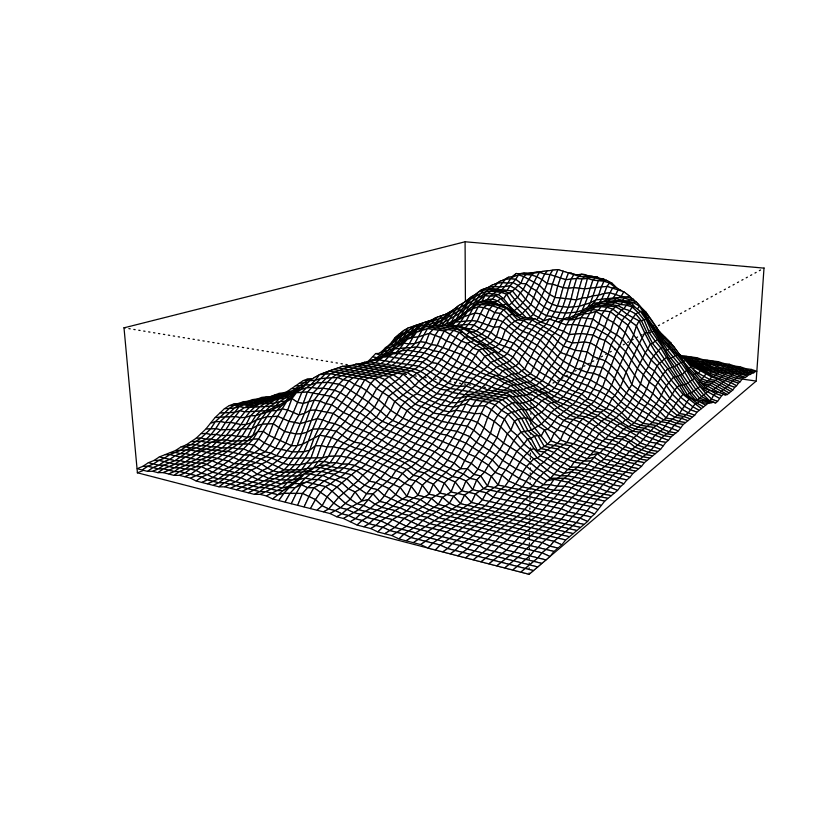


> title(main = "Maunga Whau\nOne of 50 Volcanoes in the Auckland Region.",
+       font.main = 4)

> par(bg = "slategray")

> persp(x, y, z, theta = 135, phi = 30, col = fill, scale = FALSE,
+       ltheta = -120, lphi = 15, shade = 0.65, axes = FALSE)


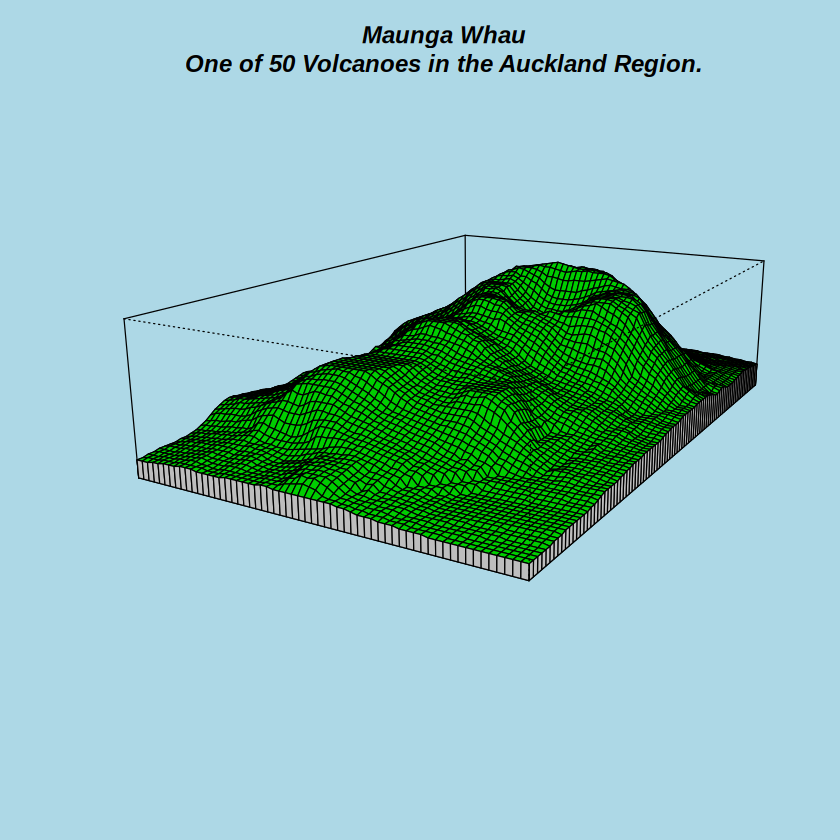


> ## Don't draw the grid lines :  border = NA
> persp(x, y, z, theta = 135, phi = 30, col = "green3", scale = FALSE,
+       ltheta = -120, shade = 0.75, border = NA, box = FALSE)


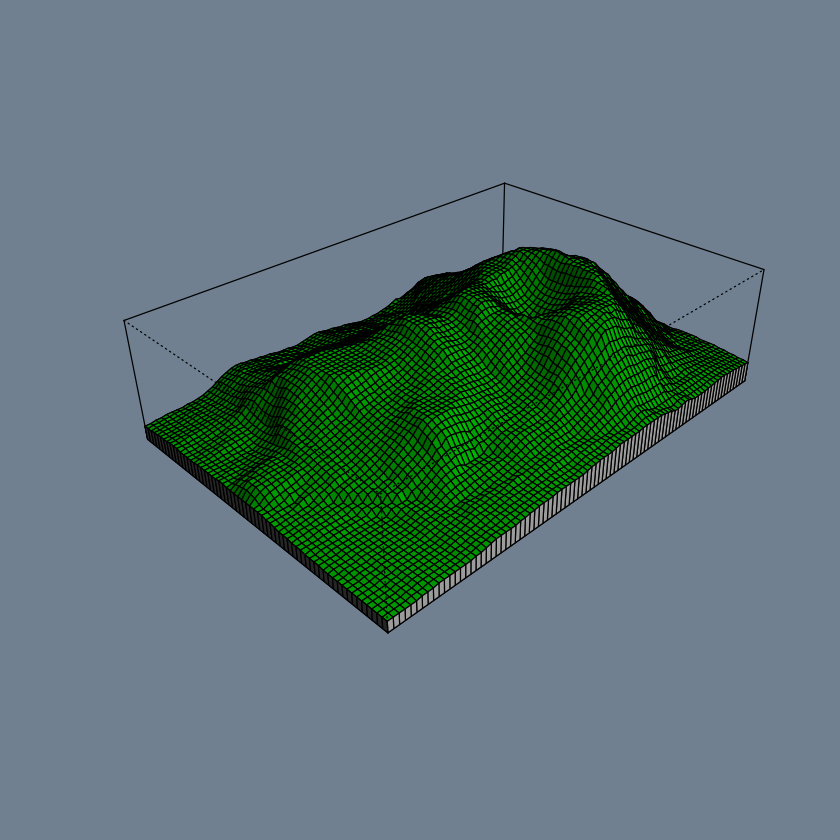


> ## `color gradient in the soil' :
> fcol <- fill ; fcol[] <- terrain.colors(nrow(fcol))

> persp(x, y, z, theta = 135, phi = 30, col = fcol, scale = FALSE,
+       ltheta = -120, shade = 0.3, border = NA, box = FALSE)


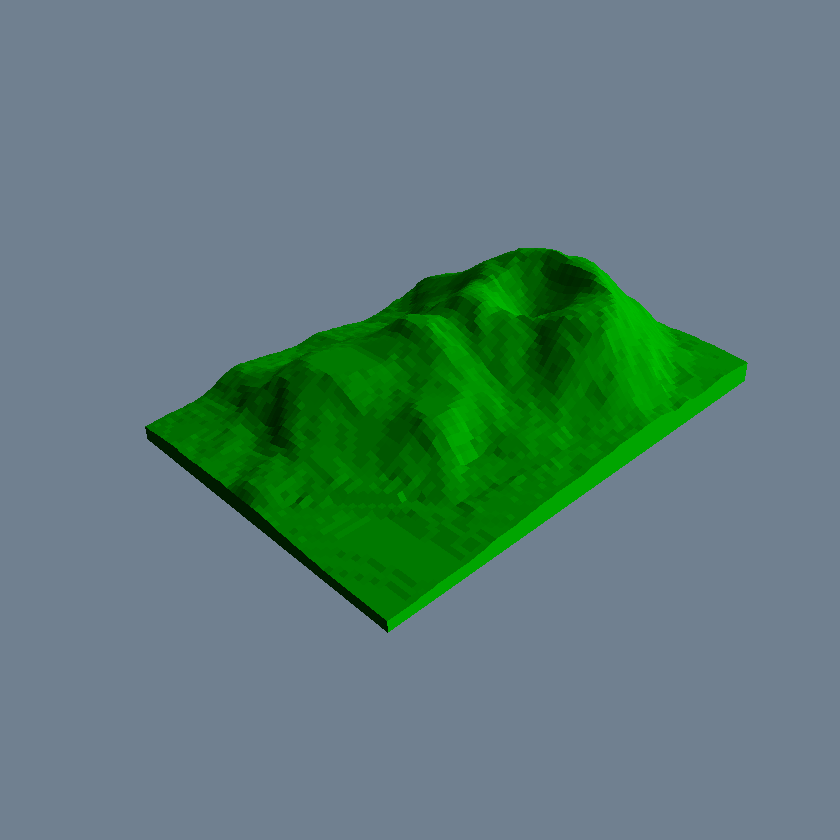


> ## `image like' colors on top :
> fcol <- fill

> zi <- volcano[ -1,-1] + volcano[ -1,-61] +
+            volcano[-87,-1] + volcano[-87,-61]  ## / 4

> fcol[-i1,-i2] <-
+     terrain.colors(20)[cut(zi,
+                            stats::quantile(zi, seq(0,1, length.out = 21)),
+                            include.lowest = TRUE)]

> persp(x, y, 2*z, theta = 110, phi = 40, col = fcol, scale = FALSE,
+       ltheta = -120, shade = 0.4, border = NA, box = FALSE)


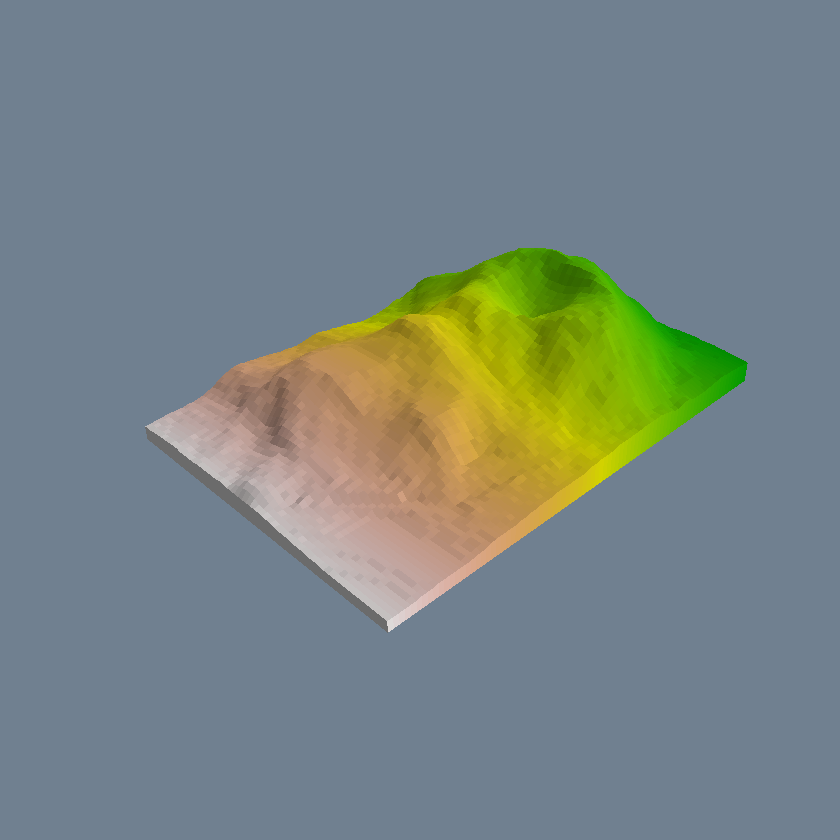


> ## reset par():
> par(oldpar)


	demo(graphics)
	---- ~~~~~~~~

> #  Copyright (C) 1997-2009 The R Core Team
> 
> require(datasets)

> require(grDevices); require(graphics)

> ## Here is some code which illustrates some of the differences between
> ## R and S graphics capabilities.  Note that colors are generally specified
> ## by a character string name (taken from the X11 rgb.txt file) and that line
> ## textures are given similarly.  The parameter "bg" sets the background
> ## parameter for the plot and there is also an "fg" parameter which sets
> ## the foreground color.
> 
> 
> x <- stats::rnorm(50)

> opar <- par(bg = "white")

> plot(x, ann = FALSE, type = "n")


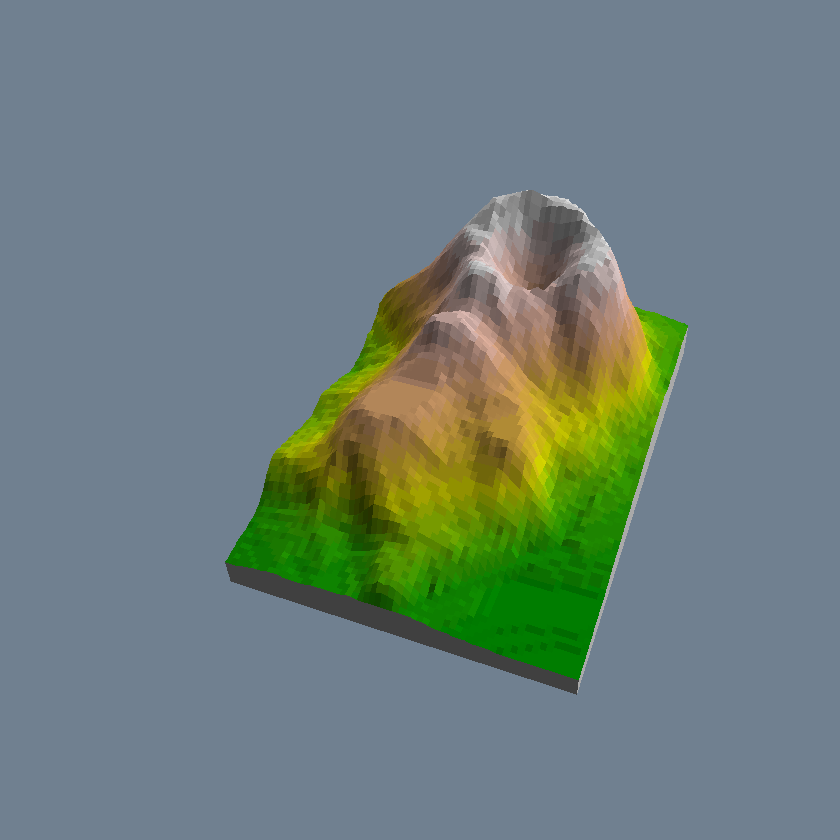


> abline(h = 0, col = gray(.90))

> lines(x, col = "green4", lty = "dotted")

> points(x, bg = "limegreen", pch = 21)

> title(main = "Simple Use of Color In a Plot",
+       xlab = "Just a Whisper of a Label",
+       col.main = "blue", col.lab = gray(.8),
+       cex.main = 1.2, cex.lab = 1.0, font.main = 4, font.lab = 3)

> ## A little color wheel.	 This code just plots equally spaced hues in
> ## a pie chart.	If you have a cheap SVGA monitor (like me) you will
> ## probably find that numerically equispaced does not mean visually
> ## equispaced.  On my display at home, these colors tend to cluster at
> ## the RGB primaries.  On the other hand on the SGI Indy at work the
> ## effect is near perfect.
> 
> par(bg = "gray")

> pie(rep(1,24), col = rainbow(24), radius = 0.9)


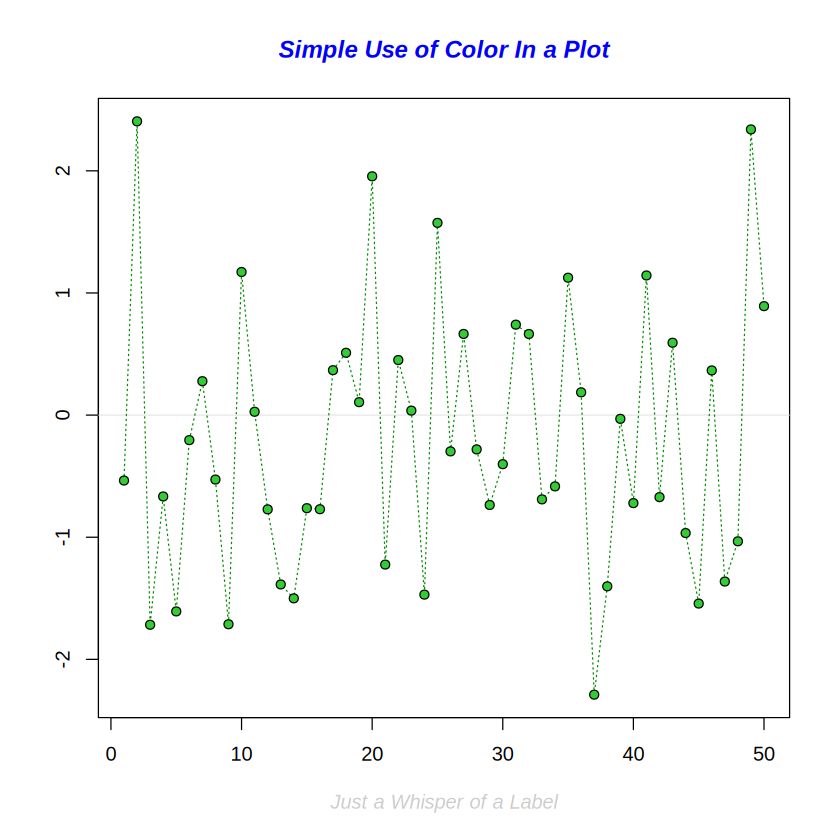


> title(main = "A Sample Color Wheel", cex.main = 1.4, font.main = 3)

> title(xlab = "(Use this as a test of monitor linearity)",
+       cex.lab = 0.8, font.lab = 3)

> ## We have already confessed to having these.  This is just showing off X11
> ## color names (and the example (from the postscript manual) is pretty "cute".
> 
> pie.sales <- c(0.12, 0.3, 0.26, 0.16, 0.04, 0.12)

> names(pie.sales) <- c("Blueberry", "Cherry",
+ 		      "Apple", "Boston Cream", "Other", "Vanilla Cream")

> pie(pie.sales,
+     col = c("purple","violetred1","green3","cornsilk","cyan","white"))


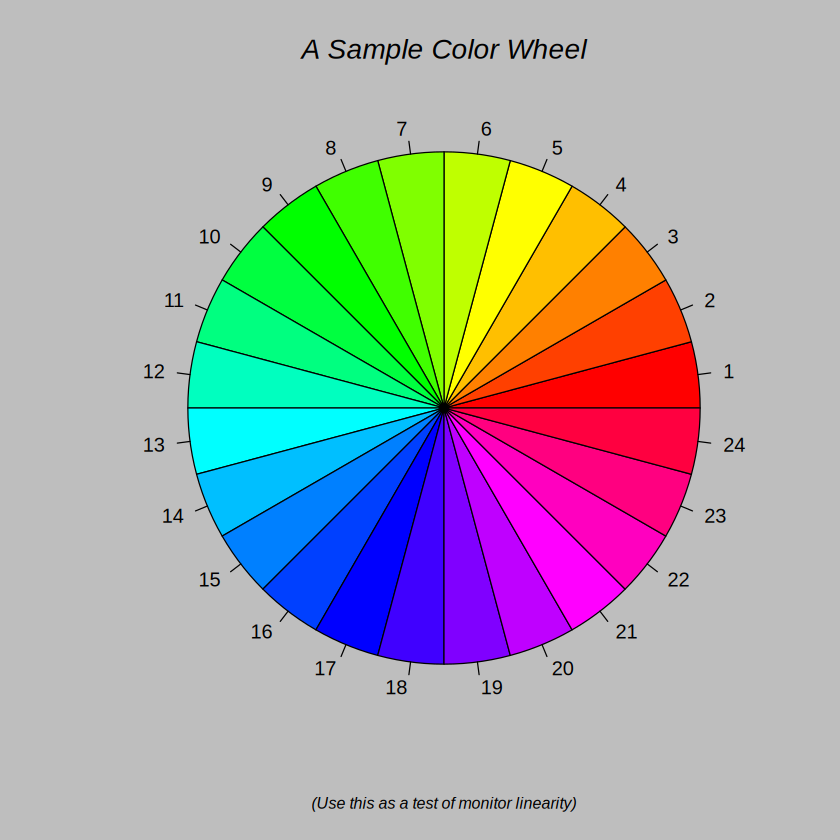


> title(main = "January Pie Sales", cex.main = 1.8, font.main = 1)

> title(xlab = "(Don't try this at home kids)", cex.lab = 0.8, font.lab = 3)

> ## Boxplots:  I couldn't resist the capability for filling the "box".
> ## The use of color seems like a useful addition, it focuses attention
> ## on the central bulk of the data.
> 
> par(bg="cornsilk")

> n <- 10

> g <- gl(n, 100, n*100)

> x <- rnorm(n*100) + sqrt(as.numeric(g))

> boxplot(split(x,g), col="lavender", notch=TRUE)


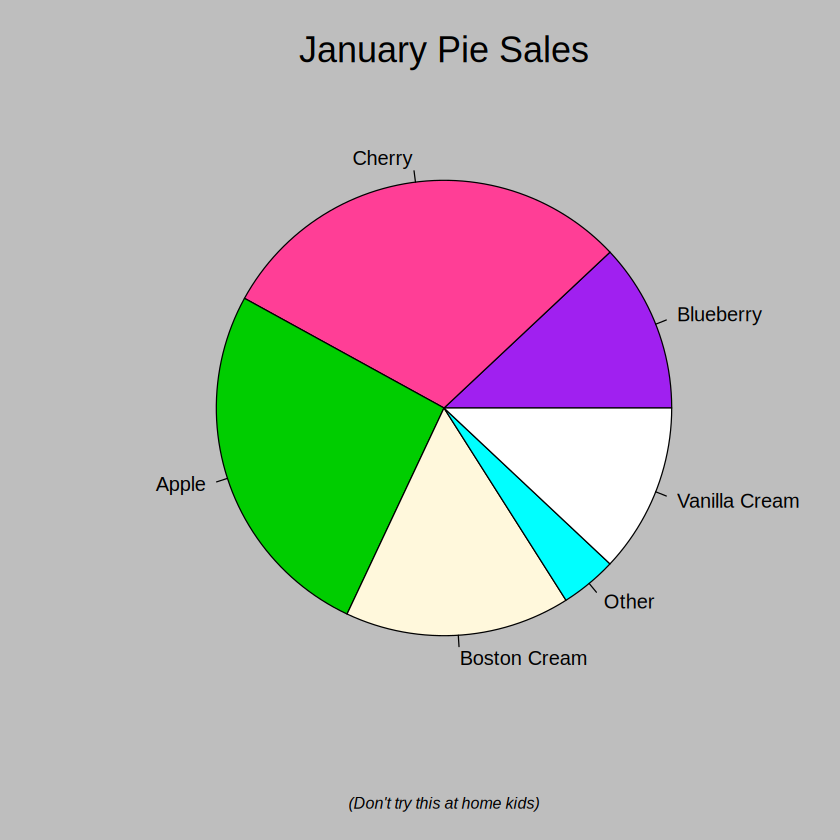


> title(main="Notched Boxplots", xlab="Group", font.main=4, font.lab=1)

> ## An example showing how to fill between curves.
> 
> par(bg="white")

> n <- 100

> x <- c(0,cumsum(rnorm(n)))

> y <- c(0,cumsum(rnorm(n)))

> xx <- c(0:n, n:0)

> yy <- c(x, rev(y))

> plot(xx, yy, type="n", xlab="Time", ylab="Distance")


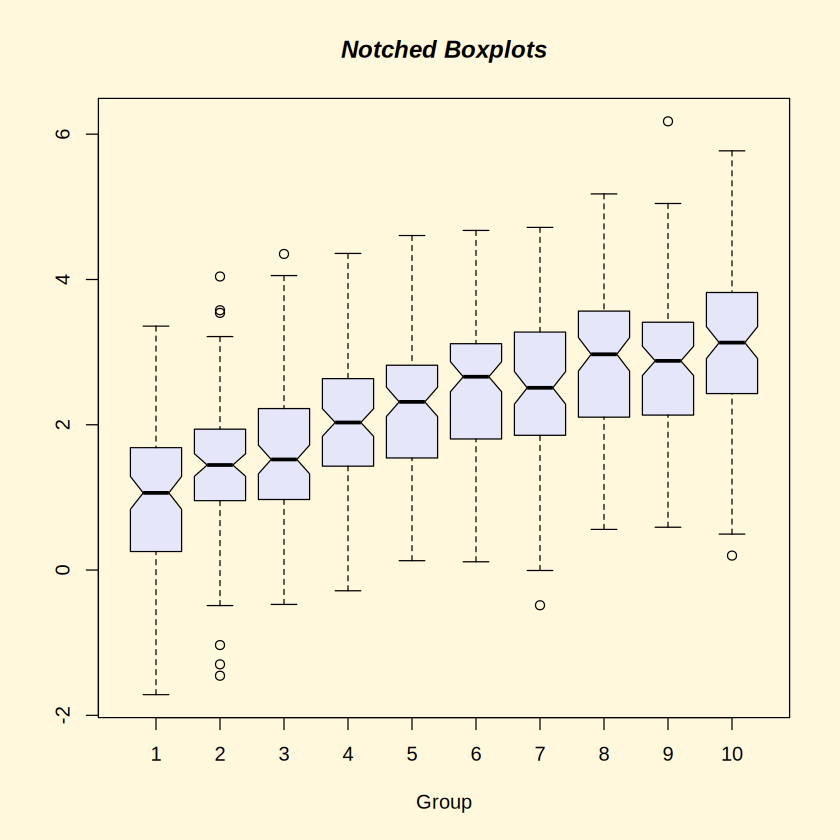


> polygon(xx, yy, col="gray")

> title("Distance Between Brownian Motions")

> ## Colored plot margins, axis labels and titles.	 You do need to be
> ## careful with these kinds of effects.	It's easy to go completely
> ## over the top and you can end up with your lunch all over the keyboard.
> ## On the other hand, my market research clients love it.
> 
> x <- c(0.00, 0.40, 0.86, 0.85, 0.69, 0.48, 0.54, 1.09, 1.11, 1.73, 2.05, 2.02)

> par(bg="lightgray")

> plot(x, type="n", axes=FALSE, ann=FALSE)


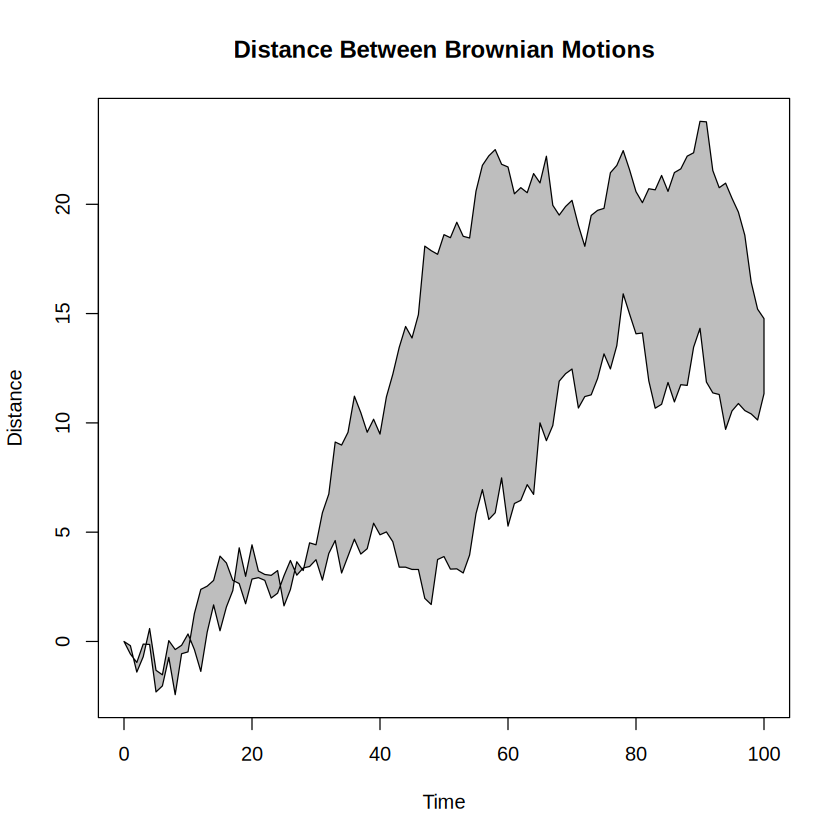


> usr <- par("usr")

> rect(usr[1], usr[3], usr[2], usr[4], col="cornsilk", border="black")

> lines(x, col="blue")

> points(x, pch=21, bg="lightcyan", cex=1.25)

> axis(2, col.axis="blue", las=1)

> axis(1, at=1:12, lab=month.abb, col.axis="blue")

> box()

> title(main= "The Level of Interest in R", font.main=4, col.main="red")

> title(xlab= "1996", col.lab="red")

> ## A filled histogram, showing how to change the font used for the
> ## main title without changing the other annotation.
> 
> par(bg="cornsilk")

> x <- rnorm(1000)

> hist(x, xlim=range(-4, 4, x), col="lavender", main="")


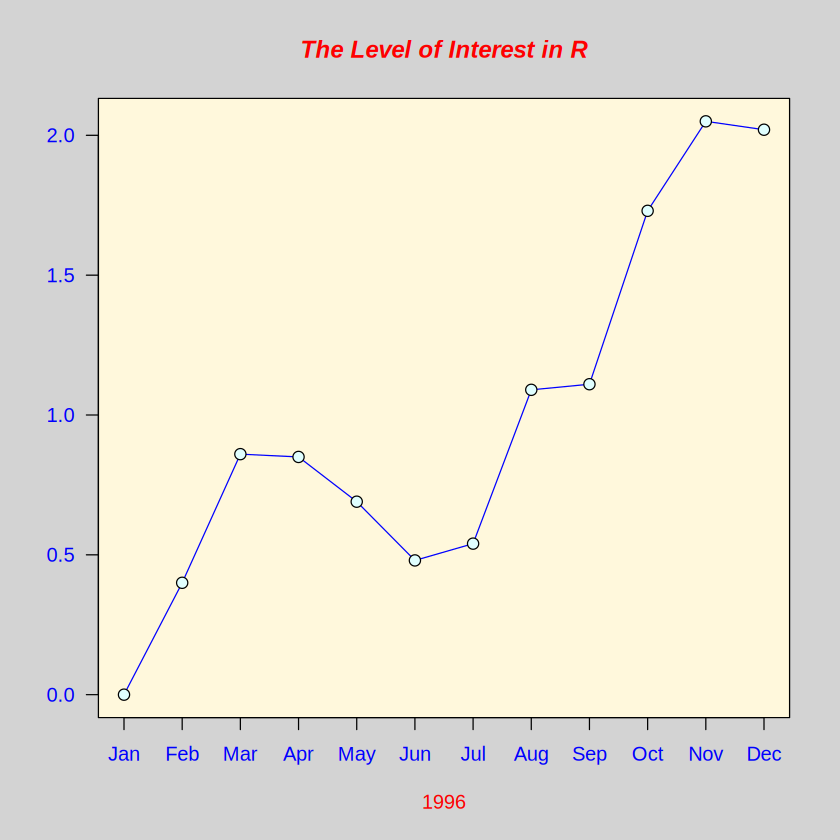


> title(main="1000 Normal Random Variates", font.main=3)

> ## A scatterplot matrix
> ## The good old Iris data (yet again)
> 
> pairs(iris[1:4], main="Edgar Anderson's Iris Data", font.main=4, pch=19)


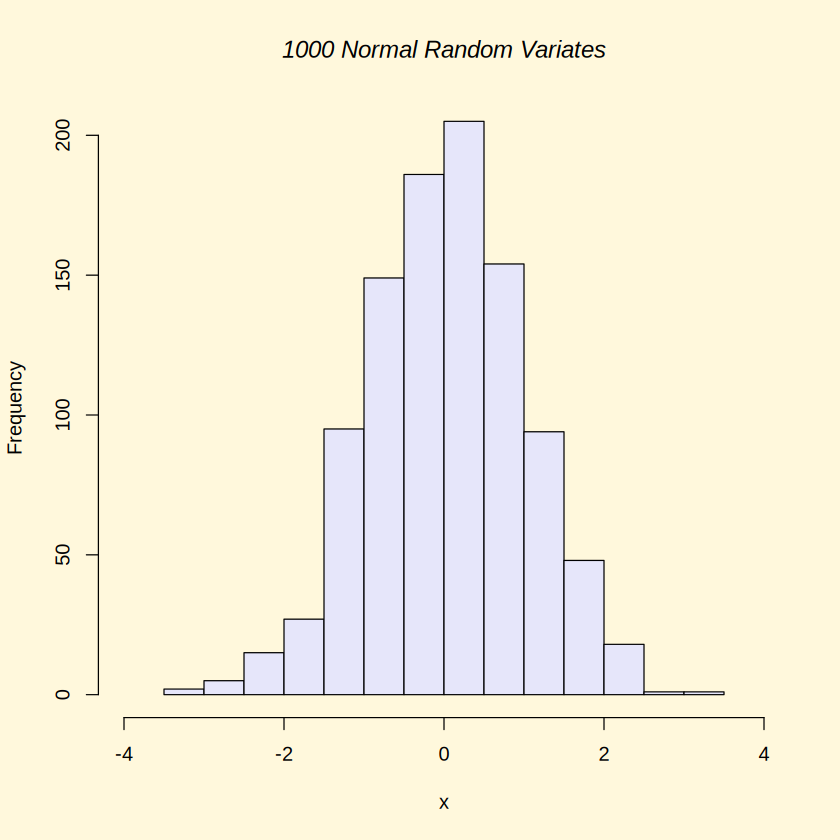


> pairs(iris[1:4], main="Edgar Anderson's Iris Data", pch=21,
+       bg = c("red", "green3", "blue")[unclass(iris$Species)])


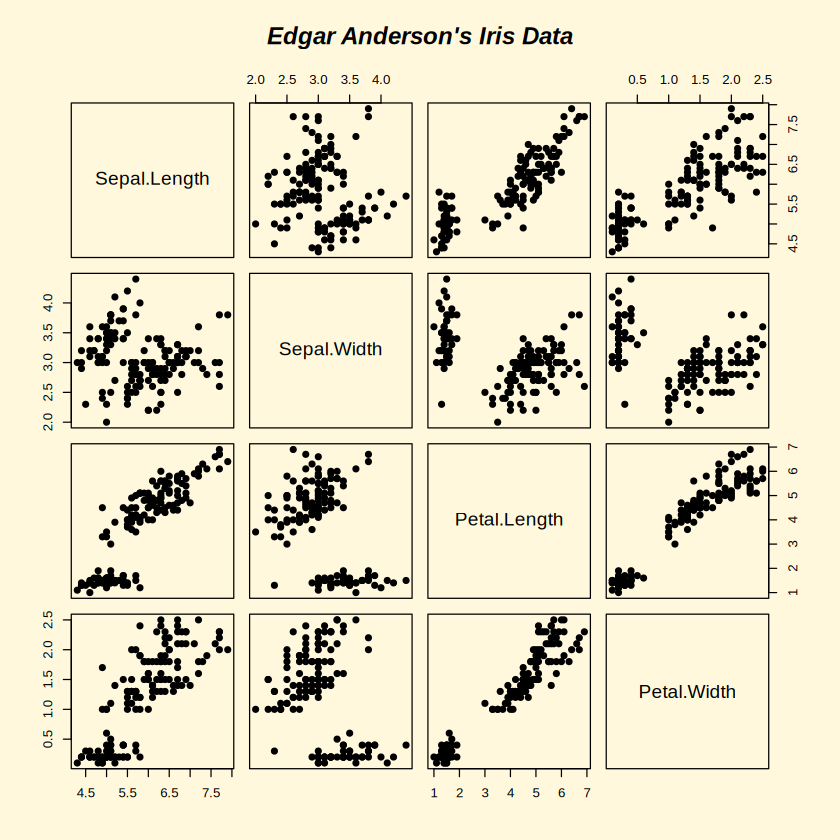


> ## Contour plotting
> ## This produces a topographic map of one of Auckland's many volcanic "peaks".
> 
> x <- 10*1:nrow(volcano)

> y <- 10*1:ncol(volcano)

> lev <- pretty(range(volcano), 10)

> par(bg = "lightcyan")

> pin <- par("pin")

> xdelta <- diff(range(x))

> ydelta <- diff(range(y))

> xscale <- pin[1]/xdelta

> yscale <- pin[2]/ydelta

> scale <- min(xscale, yscale)

> xadd <- 0.5*(pin[1]/scale - xdelta)

> yadd <- 0.5*(pin[2]/scale - ydelta)

> plot(numeric(0), numeric(0),
+      xlim = range(x)+c(-1,1)*xadd, ylim = range(y)+c(-1,1)*yadd,
+      type = "n", ann = FALSE)


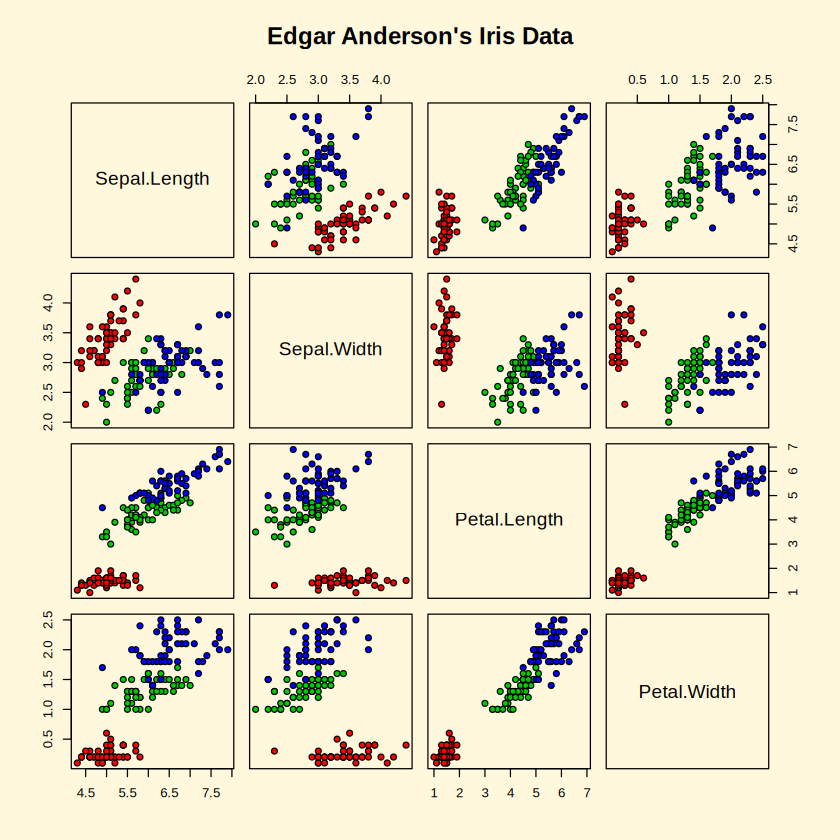


> usr <- par("usr")

> rect(usr[1], usr[3], usr[2], usr[4], col="green3")

> contour(x, y, volcano, levels = lev, col="yellow", lty="solid", add=TRUE)

> box()

> title("A Topographic Map of Maunga Whau", font= 4)

> title(xlab = "Meters North", ylab = "Meters West", font= 3)

> mtext("10 Meter Contour Spacing", side=3, line=0.35, outer=FALSE,
+       at = mean(par("usr")[1:2]), cex=0.7, font=3)

> ## Conditioning plots
> 
> par(bg="cornsilk")

> coplot(lat ~ long | depth, data = quakes, pch = 21, bg = "green3")


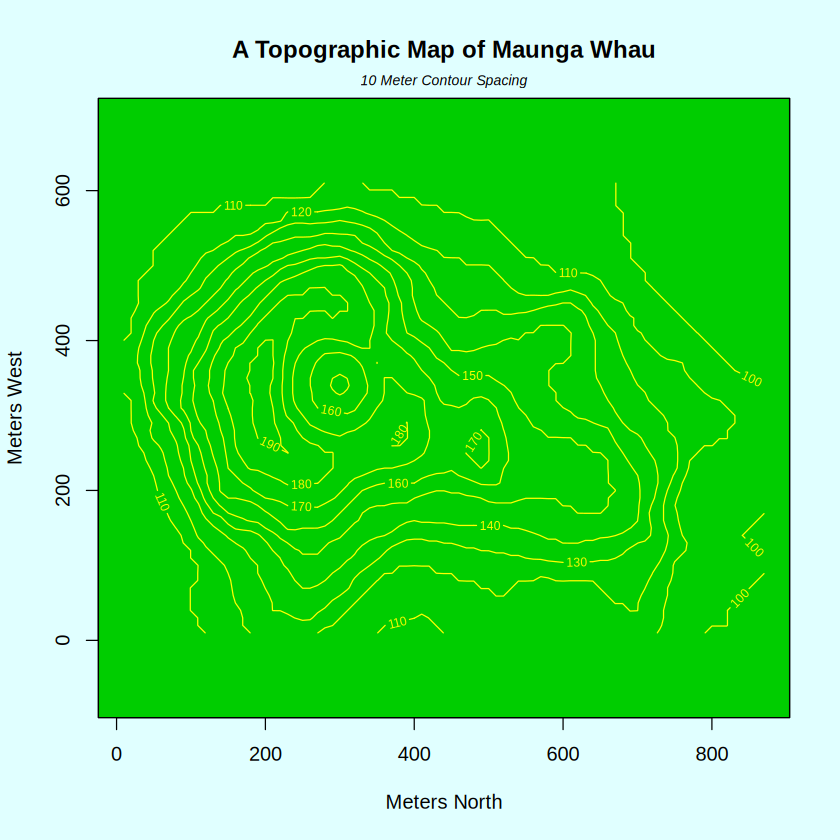


> par(opar)


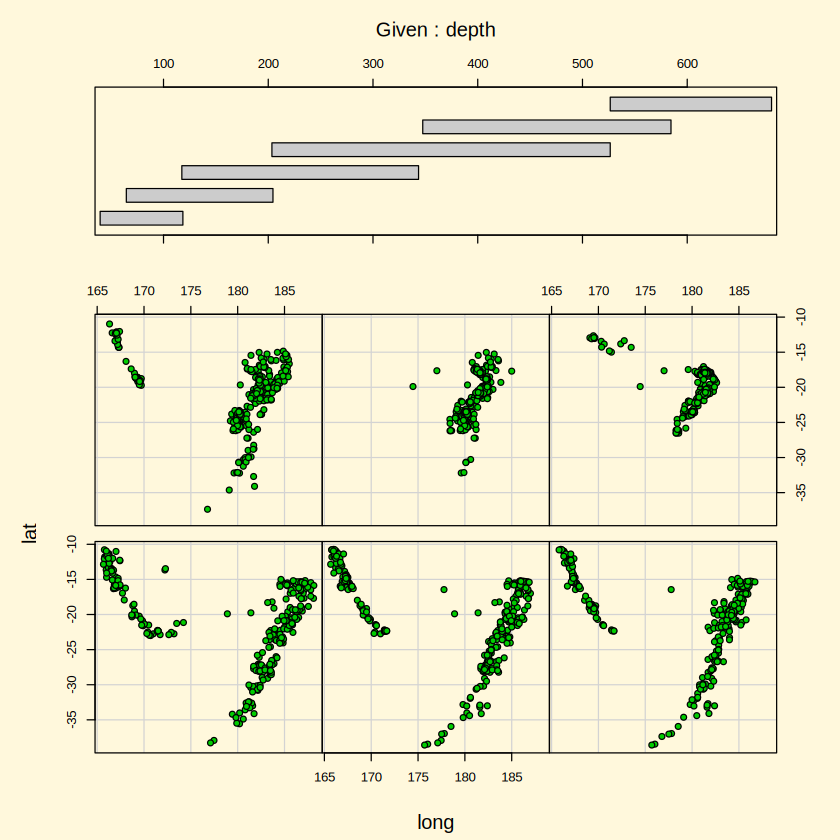

In [7]:
# Demonstration of perspective 3D surface plots
demo(persp)

# Demonstration of graphics
demo(graphics)


# Lecture 3 — Packages and Libraries in R

## 1. Loading a library/package

In [8]:
# Load the spatial package
library(spatial)


## 2. Package description

In [9]:
# Display package description
packageDescription("spatial")


Package: spatial
Priority: recommended
Version: 7.3-19
Date: 2026-08-01
Depends: R (>= 3.0.0), graphics, stats, utils
Authors@R: c(person("Brian", "Ripley", role = c("aut", "cre", "cph"),
        email = "Brian.Ripley@R-project.org"), person("Roger",
        "Bivand", role = "ctb"), person("William", "Venables", role =
        "cph"))
Description: Functions for kriging and point pattern analysis.
Title: Functions for Kriging and Point Pattern Analysis
LazyData: yes
ByteCompile: yes
License: GPL-2 | GPL-3
URL: http://www.stats.ox.ac.uk/pub/MASS4/
NeedsCompilation: yes
Packaged: 2026-08-03 06:32:27 UTC; ripley
Author: Brian Ripley [aut, cre, cph], Roger Bivand [ctb], William
        Venables [cph]
Maintainer: Brian Ripley <Brian.Ripley@R-project.org>
Repository: CRAN
Date/Publication: 2026-08-03 09:45:17 UTC
Built: R 4.6.1; x86_64-pc-linux-gnu; 2026-08-03 11:08:25 UTC; unix

-- File: /usr/lib/R/site-library/spatial/Meta/package.rds 

## 3. Display package contents

In [10]:
# Display information and contents of the spatial package
library(help = spatial)


## 4. Installing packages

The notes demonstrate installation of the `boot` and `cluster` packages.


In [11]:
# Install the boot package
install.packages("boot")

# Install the cluster package
install.packages("cluster")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## 5. List installed packages

In [12]:
# Show packages installed on the computer
installed.packages()


,Package,LibPath,Version,Priority,Depends,Imports,LinkingTo,Suggests,Enhances,License,License_is_FOSS,License_restricts_use,OS_type,MD5sum,NeedsCompilation,Built,Published
boot,boot,/usr/local/lib/R/site-library,1.3-32,recommended,"R (>= 3.0.0), graphics, stats",NA,NA,"MASS, survival",NA,Unlimited,NA,NA,NA,NA,no,R 4.6.1; ; 2026-09-28 09:05:39 UTC; unix,NA
cluster,cluster,/usr/local/lib/R/site-library,2.1.8.3,recommended,R (>= 3.5.0),"graphics, grDevices, stats, utils",NA,"MASS, Matrix","mvoutlier, fpc, ellipse, sfsmisc",GPL (>= 2),NA,NA,NA,NA,yes,R 4.6.1; x86_64-pc-linux-gnu; 2026-09-28 09:05:46 UTC; unix,NA
IRdisplay,IRdisplay,/usr/local/lib/R/site-library,1.1,NA,R (>= 3.0.1),"methods, repr",NA,"testthat, withr",NA,MIT + file LICENSE,NA,NA,NA,NA,no,R 4.6.1; ; 2026-09-16 13:15:24 UTC; unix,NA
IRkernel,IRkernel,/usr/local/lib/R/site-library,1.3.2,NA,R (>= 3.2.0),"repr (>= 0.4.99), methods, evaluate (>= 0.10), IRdisplay (>= 0.3.0.9999), pbdZMQ (>= 0.2-1), crayon, jsonlite (>= 0.9.6), uuid, digest",NA,"testthat, roxygen2",NA,MIT + file LICENSE,NA,NA,NA,NA,no,R 4.6.1; ; 2026-09-16 13:15:27 UTC; unix,NA
pbdZMQ,pbdZMQ,/usr/local/lib/R/site-library,0.3-14,NA,R (>= 3.5.0),NA,NA,NA,NA,GPL-3,NA,NA,NA,NA,yes,R 4.6.1; x86_64-pc-linux-gnu; 2026-09-16 13:15:16 UTC; unix,NA
repr,repr,/usr/local/lib/R/site-library,1.1.7,NA,R (>= 3.0.1),"utils, grDevices, htmltools, jsonlite, pillar (>= 1.4.0), base64enc",NA,"methods, highr, Cairo, stringr, testthat (>= 3.0.0), leaflet","data.table, tibble, htmlwidgets, vegalite, plotly, geojsonio",GPL (>= 3),NA,NA,NA,NA,no,R 4.6.1; ; 2026-09-16 13:15:20 UTC; unix,NA
askpass,askpass,/usr/lib/R/site-library,1.2.1,NA,NA,sys (>= 2.1),NA,testthat,NA,MIT + file LICENSE,NA,NA,NA,NA,yes,R 4.4.0; x86_64-pc-linux-gnu; 2024-10-05 04:17:58 UTC; unix,NA
backports,backports,/usr/lib/R/site-library,1.5.1,NA,R (>= 3.0.0),NA,NA,NA,NA,GPL-2 | GPL-3,NA,NA,NA,NA,yes,R 4.5.3; x86_64-pc-linux-gnu; 2026-04-03 20:52:21 UTC; unix,NA
base64enc,base64enc,/usr/lib/R/site-library,0.1-6,NA,R (>= 2.9.0),NA,NA,NA,png,GPL-2 | GPL-3,NA,NA,NA,NA,yes,R 4.5.2; x86_64-pc-linux-gnu; 2026-02-02 12:44:54 UTC; unix,NA
bit,bit,/usr/lib/R/site-library,4.6.0,NA,R (>= 3.4.0),NA,NA,"testthat (>= 3.0.0), roxygen2, knitr, markdown, rmarkdown, microbenchmark, bit64 (>= 4.0.0), ff (>= 4.0.0)",NA,GPL-2 | GPL-3,NA,NA,NA,NA,yes,R 4.4.0; x86_64-pc-linux-gnu; 2025-03-07 05:04:38 UTC; unix,NA


## 6. Remove an installed package

In [13]:
# Remove the cluster package
remove.packages("cluster")


Removing package from ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## 7. Update packages

In [14]:
# Update packages
update.packages("cluster")


## 8. Unload a package

In [15]:
# Unload the cluster package
detach("package:cluster", unload = TRUE)


ERROR: Error in detach("package:cluster", unload = TRUE): invalid 'name' argument
